# Analyse de Vidéos de Football avec IA

Ce notebook intègre le système complet d'analyse de vidéos de football qui comprend :
- Détection et suivi des joueurs et du ballon
- Estimation du mouvement de caméra
- Attribution d'équipes par couleurs
- Transformation de vue
- Calcul de possession du ballon
- Génération de données JSON structurées

## Structure du notebook :
1. **Installation et importation des dépendances**
2. **Configuration et paramètres**
3. **Traitement des vidéos**
4. **Analyse et visualisation des résultats**
5. **Export des données**


In [1]:
# Installation des dépendances nécessaires
import subprocess
import sys
import os

def install_package(package):
    """Installe un package Python via pip"""
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ Package {package} installé avec succès")
    except subprocess.CalledProcessError as e:
        print(f"❌ Erreur lors de l'installation de {package}: {e}")

# Liste des packages requis
required_packages = [
    "ultralytics",        # YOLO v8
    "supervision",        # Pour le suivi des objets
    "opencv-python",
    "numpy",
    "fastapi",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "pandas",
    "ipywidgets"          # Pour les widgets interactifs
]

print("🔧 Installation des dépendances...")
for package in required_packages:
    install_package(package)
    
print("✅ Toutes les dépendances sont installées !")


🔧 Installation des dépendances...
✅ Package ultralytics installé avec succès
✅ Package supervision installé avec succès
✅ Package opencv-python installé avec succès
✅ Package numpy installé avec succès
✅ Package fastapi installé avec succès
✅ Package scikit-learn installé avec succès
✅ Package matplotlib installé avec succès
✅ Package seaborn installé avec succès
✅ Package pandas installé avec succès
✅ Package ipywidgets installé avec succès
✅ Toutes les dépendances sont installées !


In [2]:
# Vérification et importation de tous les modules nécessaires
print("🔍 Vérification des modules...")

try:
    # Modules standards
    import cv2
    import numpy as np
    import json
    import os
    from collections import Counter
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    from pathlib import Path
    print("✅ Modules standards importés")
    
    # Modules YOLO et supervision
    from ultralytics import YOLO
    import supervision as sv
    print("✅ Modules YOLO et supervision importés")
    
    # Importation des modules personnalisés du projet
    from utils import read_video, save_video
    from trackers import Tracker
    from team_assigner import TeamAssigner
    from player_ball_assigner import PlayerBallAssigner
    from camera_movement_estimator import CameraMovementEstimator
    from view_transformer import ViewTransformer
    from color_assigner.color_assigner import ColorAssigner
    print("✅ Modules personnalisés importés")
    
    # Configuration des graphiques
    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")
    
    print("✅ Tous les modules importés avec succès !")
    print(f"📁 Répertoire de travail : {os.getcwd()}")
    
except ImportError as e:
    print(f"❌ Erreur d'importation : {e}")
    print("💡 Relancez la cellule d'installation précédente")
    print("💡 Ou installez manuellement : pip install ultralytics supervision")


🔍 Vérification des modules...
✅ Modules standards importés
✅ Modules YOLO et supervision importés
✅ Modules personnalisés importés
✅ Tous les modules importés avec succès !
📁 Répertoire de travail : c:\Users\Lenovo\Desktop\final model


In [3]:
# Configuration des répertoires et paramètres
class VideoAnalysisConfig:
    def __init__(self):
        self.input_dir = 'input_videos'
        self.output_video_dir = 'output_videos'
        self.output_json_dir = 'output_videos'
        self.stub_dir = 'stubs'
        self.model_path = 'models/best.pt'
        
        # Création des répertoires si nécessaire
        for directory in [self.input_dir, self.output_video_dir, self.stub_dir]:
            os.makedirs(directory, exist_ok=True)
            
        # Paramètres d'analyse
        self.n_clusters = 2  # Nombre de clusters pour l'assignation d'équipes
        self.fps_output = 2  # Frames par seconde pour l'export JSON
        
    def get_video_files(self):
        """Récupère la liste des fichiers vidéo dans le répertoire d'entrée"""
        video_extensions = ('.mp4', '.avi', '.mov', '.mkv')
        return [f for f in os.listdir(self.input_dir) 
                if f.lower().endswith(video_extensions)]

# Initialisation de la configuration
config = VideoAnalysisConfig()

print("📂 Configuration initialisée :")
print(f"  - Répertoire d'entrée : {config.input_dir}")
print(f"  - Répertoire de sortie : {config.output_video_dir}")
print(f"  - Modèle YOLO : {config.model_path}")
print(f"  - Vidéos disponibles : {len(config.get_video_files())}")

# Affichage des vidéos disponibles
video_files = config.get_video_files()
if video_files:
    print("\n📹 Vidéos trouvées :")
    for i, video in enumerate(video_files, 1):
        print(f"  {i}. {video}")
else:
    print("\n⚠️  Aucune vidéo trouvée dans le répertoire input_videos")
    print("   Veuillez placer vos vidéos dans ce répertoire avant de continuer.")


📂 Configuration initialisée :
  - Répertoire d'entrée : input_videos
  - Répertoire de sortie : output_videos
  - Modèle YOLO : models/best.pt
  - Vidéos disponibles : 4

📹 Vidéos trouvées :
  1. astonvscarddiff_sequ1 (1).mp4
  2. FCBvsCITY_sequ2.mp4
  3. manchvsplymo_sequ10.mp4
  4. Match02_seq_08.mp4


In [4]:
# Fonction principale de traitement vidéo (adaptée du main.py)
def process_video_jupyter(video_path, config, show_progress=True):
    """
    Traite une vidéo et retourne les résultats pour analyse dans Jupyter
    
    Args:
        video_path (str): Chemin vers la vidéo à traiter
        config (VideoAnalysisConfig): Configuration du système
        show_progress (bool): Afficher le progrès
    
    Returns:
        dict: Dictionnaire contenant tous les résultats d'analyse
    """
    
    if show_progress:
        print(f"🎬 Traitement de : {os.path.basename(video_path)}")
    
    # 1. Lecture de la vidéo
    if show_progress:
        print("  📖 Lecture des frames...")
    video_frames = read_video(video_path)
    
    # 2. Initialisation du tracker
    if show_progress:
        print("  🔍 Initialisation du tracker...")
    tracker = Tracker(config.model_path)
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    stub_path = os.path.join(config.stub_dir, f'track_stubs_{video_name}.pkl')
    
    # 3. Détection et suivi des objets
    if show_progress:
        print("  🎯 Détection et suivi des objets...")
    tracks = tracker.get_object_tracks(video_frames, read_from_stub=True, stub_path=stub_path)
    tracker.add_position_to_tracks(tracks)
    
    # 4. Estimation du mouvement de caméra
    if show_progress:
        print("  📹 Estimation du mouvement de caméra...")
    camera_movement_estimator = CameraMovementEstimator(video_frames[0])
    camera_stub_path = os.path.join(config.stub_dir, f'camera_movement_stub_{video_name}.pkl')
    camera_movement_per_frame = camera_movement_estimator.get_camera_movement(
        video_frames, read_from_stub=True, stub_path=camera_stub_path
    )
    camera_movement_estimator.add_adjust_positions_to_tracks(tracks, camera_movement_per_frame)
    
    # 5. Transformation de vue
    if show_progress:
        print("  🔄 Transformation de vue...")
    view_transformer = ViewTransformer()
    view_transformer.add_transformed_position_to_tracks(tracks)
    
    # 6. Interpolation du ballon
    if show_progress:
        print("  ⚽ Interpolation des positions du ballon...")
    tracks["ball"] = tracker.interpolate_ball_positions(tracks["ball"])
    
    # 7. Attribution des équipes
    if show_progress:
        print("  👥 Attribution des équipes...")
    color_assigner = ColorAssigner(n_clusters=config.n_clusters)
    team_assigner = TeamAssigner()
    team_assigner.assign_team_color(video_frames[0], tracks['players'][0])
    
    # Attribution des équipes pour tous les frames
    num_frames = min(len(video_frames), len(tracks['players']))
    for frame_num in range(num_frames):
        player_track = tracks['players'][frame_num]
        for player_id, track in player_track.items():
            if 'bbox' not in track or not track['bbox']:
                continue
            team = team_assigner.get_player_team(video_frames[frame_num], track['bbox'], player_id)
            tracks['players'][frame_num][player_id]['team'] = team
            tracks['players'][frame_num][player_id]['team_color'] = team_assigner.team_colors[team]
    
    # 8. Attribution de possession du ballon
    if show_progress:
        print("  ⚽ Analyse de possession du ballon...")
    player_assigner = PlayerBallAssigner()
    team_ball_control = []
    for frame_num, player_track in enumerate(tracks['players']):
        ball_bbox = tracks['ball'][frame_num][1]['bbox']
        assigned_player = player_assigner.assign_ball_to_player(player_track, ball_bbox)
        if assigned_player != -1 and assigned_player in player_track:
            if 'team' in player_track[assigned_player]:
                tracks['players'][frame_num][assigned_player]['has_ball'] = True
                team_ball_control.append(player_track[assigned_player]['team'])
            else:
                team_ball_control.append(None)
        else:
            team_ball_control.append(team_ball_control[-1] if team_ball_control else 1)
    
    team_ball_control = np.array(team_ball_control)
    
    # 9. Calcul des statistiques de possession
    filtered_ball_control = [team for team in team_ball_control if team is not None]
    ball_control_counts = Counter(filtered_ball_control)
    least_possession_team = None
    if ball_control_counts:
        least_possession_team = ball_control_counts.most_common()[-1][0]
    
    if show_progress:
        print(f"  ✅ Traitement terminé !")
        print(f"     - Équipe avec moins de possession : Équipe {least_possession_team}")
        print(f"     - Frames traités : {len(video_frames)}")
    
    # Retour des résultats
    return {
        'video_name': video_name,
        'video_frames': video_frames,
        'tracks': tracks,
        'camera_movement': camera_movement_per_frame,
        'team_ball_control': team_ball_control,
        'ball_control_counts': ball_control_counts,
        'least_possession_team': least_possession_team,
        'team_colors': team_assigner.team_colors,
        'tracker': tracker,
        'camera_estimator': camera_movement_estimator
    }

print("✅ Fonction de traitement vidéo définie !")


✅ Fonction de traitement vidéo définie !


In [5]:
# Traitement d'une vidéo (remplacez par le nom de votre vidéo)
video_files = config.get_video_files()

if video_files:
    # Sélection de la première vidéo disponible
    selected_video = video_files[0]
    video_path = os.path.join(config.input_dir, selected_video)
    
    print(f"🎬 Traitement de la vidéo : {selected_video}")
    print("⏳ Veuillez patienter, le traitement peut prendre plusieurs minutes...")
    
    # Traitement de la vidéo
    results = process_video_jupyter(video_path, config, show_progress=True)
    
    print(f"\n✅ Traitement terminé pour {selected_video}")
    print(f"📊 Résultats disponibles dans la variable 'results'")
    
else:
    print("⚠️ Aucune vidéo trouvée. Veuillez placer une vidéo dans le répertoire 'input_videos'")
    results = None


🎬 Traitement de la vidéo : astonvscarddiff_sequ1 (1).mp4
⏳ Veuillez patienter, le traitement peut prendre plusieurs minutes...
🎬 Traitement de : astonvscarddiff_sequ1 (1).mp4
  📖 Lecture des frames...
  🔍 Initialisation du tracker...
  🎯 Détection et suivi des objets...
  📹 Estimation du mouvement de caméra...
  🔄 Transformation de vue...
  ⚽ Interpolation des positions du ballon...
  👥 Attribution des équipes...
  ⚽ Analyse de possession du ballon...
  ✅ Traitement terminé !
     - Équipe avec moins de possession : Équipe 2
     - Frames traités : 193

✅ Traitement terminé pour astonvscarddiff_sequ1 (1).mp4
📊 Résultats disponibles dans la variable 'results'


📊 STATISTIQUES DE POSSESSION DU BALLON
Équipe 1: 184 frames (95.3%) - Couleur RGB: [     163.16      182.91      168.14]
Équipe 2: 9 frames (4.7%) - Couleur RGB: [     145.74      113.94      96.687]

Équipe avec moins de possession: Équipe 2


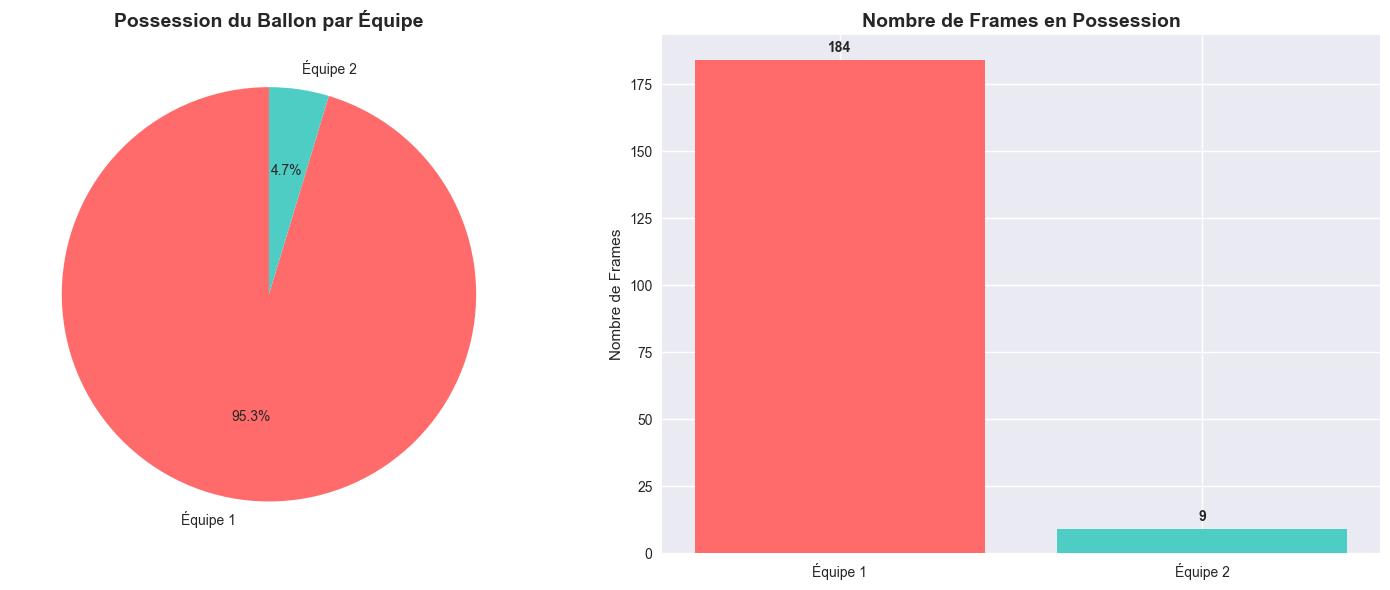

In [6]:
# Visualisation des statistiques de possession du ballon
if results is not None:
    
    # 1. Statistiques générales
    print("📊 STATISTIQUES DE POSSESSION DU BALLON")
    print("=" * 50)
    
    ball_control = results['ball_control_counts']
    total_frames = sum(ball_control.values())
    
    for team, count in ball_control.most_common():
        percentage = (count / total_frames) * 100
        color_rgb = results['team_colors'].get(team, [0, 0, 0])
        print(f"Équipe {team}: {count} frames ({percentage:.1f}%) - Couleur RGB: {color_rgb}")
    
    print(f"\nÉquipe avec moins de possession: Équipe {results['least_possession_team']}")
    
    # 2. Graphique en camembert
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Camembert
    teams = list(ball_control.keys())
    counts = list(ball_control.values())
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    
    ax1.pie(counts, labels=[f'Équipe {team}' for team in teams], 
            autopct='%1.1f%%', colors=colors[:len(teams)], startangle=90)
    ax1.set_title('Possession du Ballon par Équipe', fontsize=14, fontweight='bold')
    
    # Graphique en barres
    ax2.bar([f'Équipe {team}' for team in teams], counts, color=colors[:len(teams)])
    ax2.set_title('Nombre de Frames en Possession', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Nombre de Frames')
    
    # Ajout des valeurs sur les barres
    for i, count in enumerate(counts):
        ax2.text(i, count + max(counts)*0.01, str(count), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Aucun résultat disponible. Veuillez d'abord traiter une vidéo.")


In [7]:
# Correction de la fonction export_detections_to_json pour sauvegarder le fichier dans output_videos
import os
def export_detections_to_json(results, output_path=None, seq_id=None, fps=25):
    """Exporte les positions des joueurs détectés dans un fichier JSON dans output_videos"""
    if seq_id is None:
        seq_id = results.get('video_name', None)
    detections = {"id_sequence": seq_id, "frames": []}
    num_frames = len(results['video_frames'])
    
    for frame_num in range(num_frames):
        joueurs = []
        for player_id, track in results['tracks']['players'][frame_num].items():
            pos_transformed = track.get('position_transformed', None)
            if pos_transformed is not None:
                x, y = pos_transformed
                joueurs.append({"id": int(player_id), "x": float(x), "y": float(y)})
            elif 'bbox' in track and track['bbox']:
                x_min, y_min, x_max, y_max = track['bbox']
                x, y = (x_min + x_max)/2, (y_min + y_max)/2
                joueurs.append({"id": int(player_id), "x": float(x), "y": float(y)})
        time_sec = frame_num / fps
        detections["frames"].append({"temps": round(time_sec, 2), "joueurs": joueurs})
    
    # Définir le chemin de sortie dans output_videos si non fourni
    if output_path is None:
        os.makedirs("output_videos", exist_ok=True)
        output_path = os.path.join("output_videos", "detections.json")
    
    with open(output_path, "w") as f:
        import json
        json.dump(detections, f, indent=2)
    
    print(f"✅ detections.json sauvegardé ({len(detections['frames'])} frames) → {output_path}")
    return detections

# Exemple d'utilisation après avoir exécuté process_video_jupyter :
if results is not None:
    detections = export_detections_to_json(results)

✅ detections.json sauvegardé (193 frames) → output_videos\detections.json


# 🧮 Calcul et Analyse des Features Tactiques

Cette section intègre le système de calcul de features tactiques pour analyser les séquences de jeu et identifier les patterns tactiques (pressing haut, bloc bas, etc.).

## Features calculées :
1. **Distance barycentre défense vs attaque** - Mesure l'écartement des équipes
2. **Nombre d'attaquants dans la zone défensive** - Indicateur de pressing
3. **Ratio de joueurs dans le tiers défensif** - Position défensive
4. **Distance moyenne au barycentre** - Compacité de l'équipe
5. **Aire englobante** - Surface couverte par l'équipe
6. **Barycentre X** - Position horizontale moyenne
7. **Écart-type des distances** - Dispersion de l'équipe
8. **Hauteur moyenne Y** - Position verticale moyenne
9. **Écart-type en Y** - Dispersion verticale
10. **Densité** - Concentration des joueurs


In [8]:
# Fonction de calcul des features tactiques (intégrée du calcul_features.ipynb)
def calculate_tactical_features(frames_data, team_with_least_possession=None):
    """
    Calcule les 10 features tactiques pour une séquence de frames
    
    Args:
        frames_data (list): Liste des frames avec données des joueurs
        team_with_least_possession (int): Équipe avec moins de possession (défensive)
    
    Returns:
        list: Liste des features pour chaque frame
    """
    import numpy as np
    
    all_features = []
    
    for frame in frames_data:
        joueurs = frame.get("joueurs", [])
        nb_joueurs = len(joueurs)
        
        # Initialiser les 10 features à 0.0
        features = [0.0] * 10
        
        # Déterminer l'équipe défensive
        def_team = frame.get("team_with_least_possession") or team_with_least_possession
        if def_team not in [1, 2] or nb_joueurs < 4:
            all_features.append(features)
            continue
            
        att_team = 2 if def_team == 1 else 1
        
        # Séparer les joueurs par équipe
        joueurs_def = [j for j in joueurs if j.get("team") == def_team]
        joueurs_att = [j for j in joueurs if j.get("team") == att_team]
        
        # 1. Distance barycentre défense vs attaque
        if joueurs_def and joueurs_att:
            coords_def = np.array([[j["x"], j["y"]] for j in joueurs_def])
            coords_att = np.array([[j["x"], j["y"]] for j in joueurs_att])
            bary_def = np.mean(coords_def, axis=0)
            bary_att = np.mean(coords_att, axis=0)
            features[0] = float(np.linalg.norm(bary_def - bary_att))
        
        # 2. Nombre d'attaquants dans la zone défensive (Y > 540)
        attaquants_zone_def = [j for j in joueurs_att if j["y"] > 540]
        features[1] = len(attaquants_zone_def)
        
        # 3. Ratio de joueurs dans le tiers défensif (Y > 720)
        joueurs_tiers_def = [j for j in joueurs if j["y"] > 720]
        features[2] = len(joueurs_tiers_def) / nb_joueurs if nb_joueurs > 0 else 0.0
        
        # Calculs nécessitant au moins 6 joueurs
        if nb_joueurs >= 6:
            coords_all = np.array([[j["x"], j["y"]] for j in joueurs])
            barycentre = np.mean(coords_all, axis=0)
            dists_bary = np.linalg.norm(coords_all - barycentre, axis=1)
            
            # 4. Distance moyenne au barycentre
            features[3] = float(np.mean(dists_bary))
            
            # 5. Aire englobante
            min_x, min_y = np.min(coords_all, axis=0)
            max_x, max_y = np.max(coords_all, axis=0)
            aire = (max_x - min_x + 1) * (max_y - min_y + 1)
            features[4] = float(aire)
            
            # 6. Barycentre X
            features[5] = float(barycentre[0])
            
            # 7. Écart-type des distances
            features[6] = float(np.std(dists_bary))
            
            # 8. Hauteur moyenne Y
            features[7] = float(np.mean(coords_all[:, 1]))
            
            # 9. Écart-type en Y
            features[8] = float(np.std(coords_all[:, 1]))
            
            # 10. Densité (joueurs / aire)
            features[9] = float(nb_joueurs / aire) if aire > 0 else 0.0
        
        all_features.append(features)
    
    return all_features

print("✅ Fonction de calcul des features tactiques définie !")


✅ Fonction de calcul des features tactiques définie !


In [9]:
# Fonction pour générer les données JSON structurées (compatible avec calcul_features)
def generate_json_data(results, config):
    """
    Génère les données JSON dans le format attendu par le système de calcul de features
    
    Args:
        results (dict): Résultats du traitement vidéo
        config (VideoAnalysisConfig): Configuration du système
    
    Returns:
        dict: Données JSON structurées
    """
    if results is None:
        return None
    
    # Obtenir le framerate réel de la vidéo
    video_path = os.path.join(config.input_dir, f"{results['video_name']}.mp4")
    if os.path.exists(video_path):
        video_cap = cv2.VideoCapture(video_path)
        fps = video_cap.get(cv2.CAP_PROP_FPS)
        video_cap.release()
    else:
        fps = 30  # Valeur par défaut
    
    step = int(fps // config.fps_output)  # Pour config.fps_output frames par seconde
    
    frames_json = []
    for frame_num in range(0, len(results['tracks']['players']), step):
        if frame_num >= len(results['tracks']['players']):
            break
            
        player_track = results['tracks']['players'][frame_num]
        frame_data = {
            "temps": round(frame_num / fps, 2),  # temps en secondes
            "team_with_least_possession": int(results['least_possession_team']) if results['least_possession_team'] is not None else None,
            "joueurs": []
        }
        
        for player_id, track in player_track.items():
            pos = track.get('position_adjusted', track.get('position', None))
            if pos is not None:
                frame_data["joueurs"].append({
                    "id": int(player_id),
                    "x": int(pos[0]),
                    "y": int(pos[1]),
                    "team": int(track.get('team', None)) if track.get('team', None) is not None else None
                })
        
        frames_json.append(frame_data)
    
    # Création JSON final avec ajout de l'id
    json_data = {
        "id": results['video_name'],
        "frames": frames_json
    }
    
    return json_data

# Fonction pour calculer les features sur les résultats du traitement vidéo
def analyze_video_features(results, config):
    """
    Analyse les features tactiques d'une vidéo traitée
    
    Args:
        results (dict): Résultats du traitement vidéo
        config (VideoAnalysisConfig): Configuration du système
    
    Returns:
        dict: Résultats de l'analyse des features
    """
    if results is None:
        return None
    
    # Générer les données JSON
    json_data = generate_json_data(results, config)
    if json_data is None:
        return None
    
    # Calculer les features tactiques
    features = calculate_tactical_features(json_data["frames"], results['least_possession_team'])
    
    # Convertir en numpy array
    features_array = np.array(features, dtype=np.float32)
    
    return {
        'video_name': results['video_name'],
        'json_data': json_data,
        'features': features,
        'features_array': features_array,
        'num_frames': len(features),
        'least_possession_team': results['least_possession_team']
    }

print("✅ Fonctions d'analyse des features définies !")


✅ Fonctions d'analyse des features définies !


In [10]:
# Calcul et analyse des features tactiques
if results is not None:
    print("🧮 Calcul des features tactiques...")
    
    # Analyser les features de la vidéo traitée
    features_analysis = analyze_video_features(results, config)
    
    if features_analysis is not None:
        print(f"✅ Features calculées pour {features_analysis['video_name']}")
        print(f"📊 Nombre de frames analysées : {features_analysis['num_frames']}")
        print(f"🏃 Équipe défensive : Équipe {features_analysis['least_possession_team']}")
        
        # Sauvegarder les données JSON
        json_output_path = os.path.join(config.output_json_dir, f"{features_analysis['video_name']}_features.json")
        with open(json_output_path, 'w') as f:
            json.dump(features_analysis['json_data'], f, indent=2)
        print(f"💾 Données JSON sauvegardées : {json_output_path}")
        
        # Sauvegarder les features
        features_output_path = os.path.join(config.output_json_dir, f"{features_analysis['video_name']}_features.npy")
        np.save(features_output_path, features_analysis['features_array'])
        print(f"💾 Features sauvegardées : {features_output_path}")
        
        # Afficher un aperçu des features
        print(f"\n📈 Aperçu des features (premiers frames) :")
        feature_names = [
            "Distance barycentre def/att",
            "Nb attaquants zone défensive", 
            "Ratio joueurs tiers défensif",
            "Distance moyenne barycentre",
            "Aire englobante",
            "Barycentre X",
            "Écart-type distance barycentre",
            "Hauteur moyenne Y",
            "Écart-type Y",
            "Densité"
        ]
        
        for frame_idx in range(min(5, len(features_analysis['features']))):
            frame_features = features_analysis['features'][frame_idx]
            print(f"\n  🕒 Frame {frame_idx + 1} :")
            for i, (name, value) in enumerate(zip(feature_names, frame_features)):
                print(f"     ▫ {name}: {value:.2f}")
        
    else:
        print("❌ Erreur lors du calcul des features")
        
else:
    print("❌ Aucun résultat disponible pour l'analyse des features")


🧮 Calcul des features tactiques...
✅ Features calculées pour astonvscarddiff_sequ1 (1)
📊 Nombre de frames analysées : 13
🏃 Équipe défensive : Équipe 2
💾 Données JSON sauvegardées : output_videos\astonvscarddiff_sequ1 (1)_features.json
💾 Features sauvegardées : output_videos\astonvscarddiff_sequ1 (1)_features.npy

📈 Aperçu des features (premiers frames) :

  🕒 Frame 1 :
     ▫ Distance barycentre def/att: 453.44
     ▫ Nb attaquants zone défensive: 1.00
     ▫ Ratio joueurs tiers défensif: 0.00
     ▫ Distance moyenne barycentre: 264.50
     ▫ Aire englobante: 407934.00
     ▫ Barycentre X: 715.14
     ▫ Écart-type distance barycentre: 132.08
     ▫ Hauteur moyenne Y: 380.43
     ▫ Écart-type Y: 101.82
     ▫ Densité: 0.00

  🕒 Frame 2 :
     ▫ Distance barycentre def/att: 389.96
     ▫ Nb attaquants zone défensive: 1.00
     ▫ Ratio joueurs tiers défensif: 0.00
     ▫ Distance moyenne barycentre: 258.92
     ▫ Aire englobante: 405552.00
     ▫ Barycentre X: 719.90
     ▫ Écart-type dis

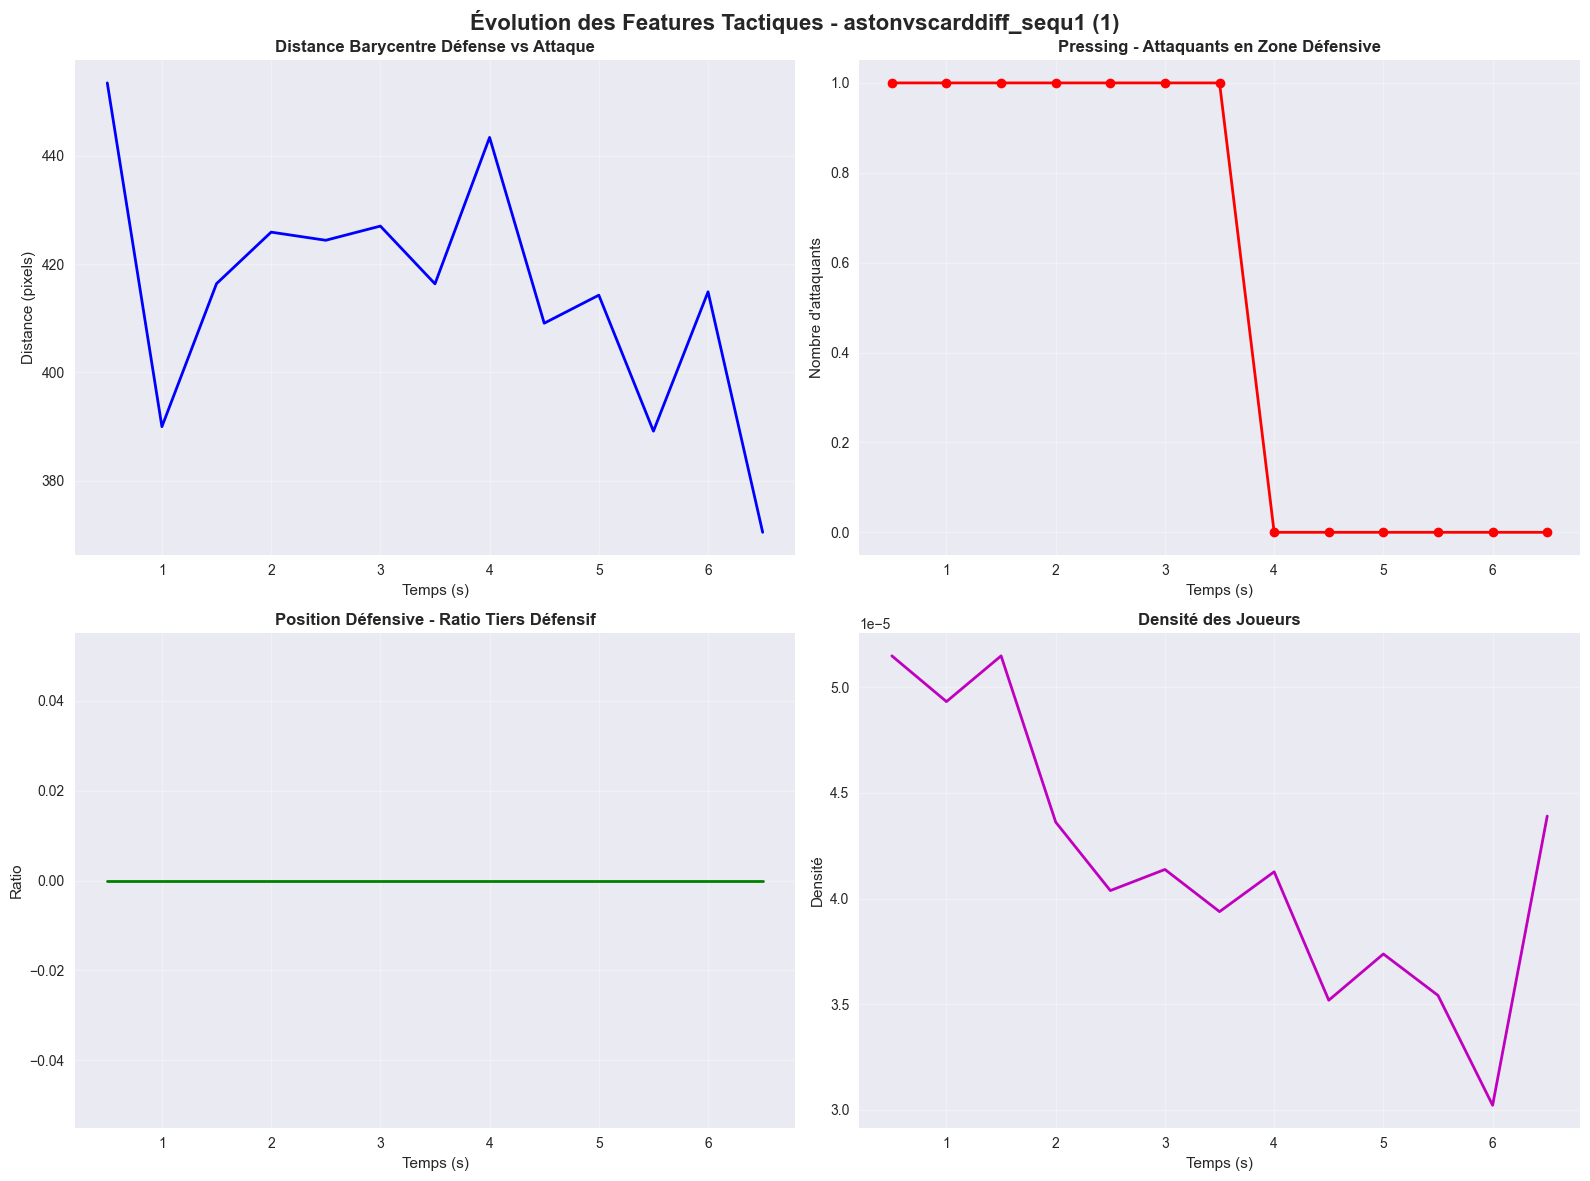

📊 STATISTIQUES DESCRIPTIVES DES FEATURES

🔸 Distance barycentre def/att:
   Moyenne: 414.96
   Écart-type: 22.28
   Min: 370.45
   Max: 453.44

🔸 Nb attaquants zone défensive:
   Moyenne: 0.54
   Écart-type: 0.52
   Min: 0.00
   Max: 1.00

🔸 Ratio joueurs tiers défensif:
   Moyenne: 0.00
   Écart-type: 0.00
   Min: 0.00
   Max: 0.00

🔸 Densité:
   Moyenne: 0.00
   Écart-type: 0.00
   Min: 0.00
   Max: 0.00

🎯 ANALYSE TACTIQUE


In [11]:
# Visualisation des features tactiques dans le temps
if 'features_analysis' in locals() and features_analysis is not None:
    
    # Préparer les données pour la visualisation
    features_array = features_analysis['features_array']
    num_frames = features_array.shape[0]
    
    # Créer un DataFrame pour faciliter l'analyse
    feature_names = [
        "Distance barycentre def/att",
        "Nb attaquants zone défensive", 
        "Ratio joueurs tiers défensif",
        "Distance moyenne barycentre",
        "Aire englobante",
        "Barycentre X",
        "Écart-type distance barycentre",
        "Hauteur moyenne Y",
        "Écart-type Y",
        "Densité"
    ]
    
    # Créer le DataFrame
    df_features = pd.DataFrame(features_array, columns=feature_names)
    df_features['frame'] = range(1, num_frames + 1)
    df_features['temps'] = df_features['frame'] * 0.5  # Supposant 2 fps
    
    # Visualisation des features les plus importantes
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Évolution des Features Tactiques - {features_analysis["video_name"]}', fontsize=16, fontweight='bold')
    
    # 1. Distance barycentre défense vs attaque
    axes[0,0].plot(df_features['temps'], df_features['Distance barycentre def/att'], 'b-', linewidth=2)
    axes[0,0].set_title('Distance Barycentre Défense vs Attaque', fontweight='bold')
    axes[0,0].set_xlabel('Temps (s)')
    axes[0,0].set_ylabel('Distance (pixels)')
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Nombre d'attaquants dans la zone défensive
    axes[0,1].plot(df_features['temps'], df_features['Nb attaquants zone défensive'], 'r-', linewidth=2, marker='o')
    axes[0,1].set_title('Pressing - Attaquants en Zone Défensive', fontweight='bold')
    axes[0,1].set_xlabel('Temps (s)')
    axes[0,1].set_ylabel('Nombre d\'attaquants')
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Ratio joueurs dans le tiers défensif
    axes[1,0].plot(df_features['temps'], df_features['Ratio joueurs tiers défensif'], 'g-', linewidth=2)
    axes[1,0].set_title('Position Défensive - Ratio Tiers Défensif', fontweight='bold')
    axes[1,0].set_xlabel('Temps (s)')
    axes[1,0].set_ylabel('Ratio')
    axes[1,0].grid(True, alpha=0.3)
    
    # 4. Densité des joueurs
    axes[1,1].plot(df_features['temps'], df_features['Densité'], 'm-', linewidth=2)
    axes[1,1].set_title('Densité des Joueurs', fontweight='bold')
    axes[1,1].set_xlabel('Temps (s)')
    axes[1,1].set_ylabel('Densité')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques descriptives
    print("📊 STATISTIQUES DESCRIPTIVES DES FEATURES")
    print("=" * 60)
    
    # Features les plus intéressantes pour l'analyse tactique
    key_features = ['Distance barycentre def/att', 'Nb attaquants zone défensive', 
                   'Ratio joueurs tiers défensif', 'Densité']
    
    for feature in key_features:
        if feature in df_features.columns:
            mean_val = df_features[feature].mean()
            std_val = df_features[feature].std()
            min_val = df_features[feature].min()
            max_val = df_features[feature].max()
            
            print(f"\n🔸 {feature}:")
            print(f"   Moyenne: {mean_val:.2f}")
            print(f"   Écart-type: {std_val:.2f}")
            print(f"   Min: {min_val:.2f}")
            print(f"   Max: {max_val:.2f}")
    
    # Analyse des patterns tactiques
    print(f"\n🎯 ANALYSE TACTIQUE")
    print("=" * 30)
    
    # Détection de phases de pressing élevé
    pressing_threshold = df_features['Nb attaquants zone défensive'].quantile(0.75)
    high_pressing_frames = df_features[df_features['Nb attaquants zone défensive'] > pressing_threshold]
    
    if len(high_pressing_frames) > 0:
        pressing_percentage = (len(high_pressing_frames) / len(df_features)) * 100
        print(f"🔥 Pressing élevé détecté sur {pressing_percentage:.1f}% du temps")
        print(f"   Seuil: {pressing_threshold:.1f} attaquants en zone défensive")
    
    # Détection de phases défensives profondes
    defensive_threshold = df_features['Ratio joueurs tiers défensif'].quantile(0.75)
    deep_defense_frames = df_features[df_features['Ratio joueurs tiers défensif'] > defensive_threshold]
    
    if len(deep_defense_frames) > 0:
        defense_percentage = (len(deep_defense_frames) / len(df_features)) * 100
        print(f"🛡️ Défense profonde détectée sur {defense_percentage:.1f}% du temps")
        print(f"   Seuil: {defensive_threshold:.2f} ratio défensif")
    
else:
    print("❌ Aucune analyse de features disponible. Traitez d'abord une vidéo.")


In [12]:
import csv
import numpy as np
import os
import json

if features_analysis is not None:
    print("\n💾 Sauvegarde finale des fichiers pour D...")

    frames = features_analysis["features"]  # liste [T_total, N_features]
    video_name = features_analysis.get("video_name", "video")  # ex: "FCBvsCITY"
    total_frames = len(frames)

    # -----------------------------
    # Génération automatique de sequence_meta.json
    # -----------------------------
    seq_length = 50  # nb de frames par séquence (modifiable)
    sequences = []
    seq_num = results['video_name']

    for start in range(0, total_frames, seq_length):
        end = min(start + seq_length - 1, total_frames - 1)
        if end <= start:
            continue

        # Extraire les features de la séquence
        seq_features = np.array(frames[start:end + 1], dtype=np.float32)

        # Classification basée sur les nouvelles définitions tactiques
        # Analyse du comportement défensif de l'équipe
        
        # Feature 1: Nombre d'attaquants en zone défensive (pressing)
        avg_attackers_def_zone = np.mean(seq_features[:, 1]) if seq_features.shape[0] > 0 else 0
        
        # Feature 2: Ratio de joueurs dans le tiers défensif (bloc bas)
        avg_def_ratio = np.mean(seq_features[:, 2]) if seq_features.shape[0] > 0 else 0
        
        # Feature 0: Distance barycentre défense vs attaque (écartement des équipes)
        avg_distance_def_att = np.mean(seq_features[:, 0]) if seq_features.shape[0] > 0 else 0
        
        # Classification selon les définitions :
        # PRESSING = défenseurs courent vers le ballon (mouvement agressif)
        # BLOC BAS = défenseurs regardent et fixent le regard (position statique)
        
        # Critères pour PRESSING :
        # - Beaucoup d'attaquants en zone défensive (pression élevée)
        # - Distance faible entre défense et attaque (pression rapprochée)
        pressing_criteria = (
            avg_attackers_def_zone >= 1.5 or  # Au moins 1.5 attaquants en zone défensive
            (avg_distance_def_att < 150 and avg_attackers_def_zone >= 1.0)  # Pression rapprochée
        )
        
        # Critères pour BLOC BAS :
        # - Peu d'attaquants en zone défensive (défense reculée)
        # - Ratio élevé de joueurs dans le tiers défensif
        bloc_bas_criteria = (
            avg_attackers_def_zone < 1.0 and  # Peu de pression offensive
            avg_def_ratio > 0.3  # Beaucoup de joueurs en défense
        )
        
        # Classification finale
        if pressing_criteria:
            label = "pressing_haut"
        elif bloc_bas_criteria:
            label = "bloc_bas"
        else:
            # Classification par défaut basée sur la distance des équipes
            if avg_distance_def_att < 200:
                label = "pressing_haut"  # Équipes rapprochées = pression
            else:
                label = "bloc_bas"  # Équipes éloignées = bloc bas

        # ID correct = "<video_name>_seq<num>"
        seq_id = f"{video_name}_seq{seq_num}"

        sequences.append({
            "id": results['video_name'],
            "start": start,
            "end": end,
            "label": label
        })

    sequence_meta = {"sequences": sequences}

    # Sauvegarde du JSON
    sequence_meta_path = os.path.join(config.output_json_dir, "sequence_meta.json")
    with open(sequence_meta_path, "w", encoding="utf-8") as f:
        json.dump(sequence_meta, f, indent=2, ensure_ascii=False)
    print(f"✅ sequence_meta.json généré et sauvegardé dans {sequence_meta_path}")

    # -----------------------------
    # Construction des features par séquence
    # -----------------------------
    all_seq_features = []
    all_labels = []

    for seq in sequence_meta["sequences"]:
        seq_id = seq["id"]
        start, end = seq["start"], seq["end"]
        label = seq["label"]

        seq_features = frames[start:end + 1]

        all_seq_features.append(np.array(seq_features, dtype=np.float32))
        all_labels.append((seq_id, label))

    # Normaliser en matrice 3D [N_seq, T_frames, N_features]
    max_len = max(seq.shape[0] for seq in all_seq_features)
    n_features = all_seq_features[0].shape[1]
    n_seq = len(all_seq_features)

    features_matrix = np.zeros((n_seq, max_len, n_features), dtype=np.float32)
    for i, seq in enumerate(all_seq_features):
        features_matrix[i, :seq.shape[0], :] = seq  # padding si besoin

    # -----------------------------
    # Sauvegarde des fichiers finaux
    # -----------------------------
    # 1) features.npy
    features_output_path = os.path.join(
        config.output_json_dir,
        f"{video_name}_features.npy"
    )
    np.save(features_output_path, features_matrix)
    print(f"✅ Features sauvegardées dans {features_output_path}")
    print(f"   Dimensions : {features_matrix.shape} (N_seq, T_frames, N_features)")

    # 2) etiquettes.csv
    etiquettes_csv_path = os.path.join(config.output_json_dir, "etiquettes.csv")
    with open(etiquettes_csv_path, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["sequence_id", "label"])
        writer.writerows(all_labels)
    print(f"✅ Étiquettes sauvegardées dans {etiquettes_csv_path}")

else:
    print("❌ Impossible de sauvegarder : features_analysis manquant")



💾 Sauvegarde finale des fichiers pour D...
✅ sequence_meta.json généré et sauvegardé dans output_videos\sequence_meta.json
✅ Features sauvegardées dans output_videos\astonvscarddiff_sequ1 (1)_features.npy
   Dimensions : (1, 13, 10) (N_seq, T_frames, N_features)
✅ Étiquettes sauvegardées dans output_videos\etiquettes.csv


In [13]:
import csv
import numpy as np
import os
import json

if features_analysis is not None:
    print("\n💾 Sauvegarde finale des fichiers pour D...")

    frames = features_analysis["features"]  # liste [T_total, N_features]
    total_frames = len(frames)

    # -----------------------------
    # Génération automatique de sequence_meta.json
    # -----------------------------
    seq_length = 50  # nb de frames par séquence (modifiable)
    sequences = []
    seq_id = 1

    for start in range(0, total_frames, seq_length):
        end = min(start + seq_length - 1, total_frames - 1)
        if end <= start:
            continue

        # Extraire les features de la séquence
        seq_features = np.array(frames[start:end + 1], dtype=np.float32)

        # Critère basé sur la feature 1 (Nb attaquants zone défensive)
        avg_pressing = np.mean(seq_features[:, 1]) if seq_features.shape[0] > 0 else 0

        # Seuil de pressing (modifiable, ici > 2 attaquants en moyenne)
        if avg_pressing >= 2:
            label = "pressing_haut"
        else:
            label = "bloc_bas"

        sequences.append({
            "id": f"seq{seq_id}",
            "start": start,
            "end": end,
            "label": label
        })
        seq_id += 1

    sequence_meta = {"sequences": sequences}

    # Sauvegarde du JSON
    sequence_meta_path = os.path.join(config.output_json_dir, "sequence_meta.json")
    with open(sequence_meta_path, "w", encoding="utf-8") as f:
        json.dump(sequence_meta, f, indent=2, ensure_ascii=False)
    print(f"✅ sequence_meta.json généré et sauvegardé dans {sequence_meta_path}")

    # -----------------------------
    # Construction des features par séquence
    # -----------------------------
    all_seq_features = []
    all_labels = []

    for seq in sequence_meta["sequences"]:
        seq_id = seq["id"]
        start, end = seq["start"], seq["end"]
        label = seq["label"]

        seq_features = frames[start:end + 1]

        all_seq_features.append(np.array(seq_features, dtype=np.float32))
        all_labels.append((seq_id, label))

    # Normaliser en matrice 3D [N_seq, T_frames, N_features]
    max_len = max(seq.shape[0] for seq in all_seq_features)
    n_features = all_seq_features[0].shape[1]
    n_seq = len(all_seq_features)

    features_matrix = np.zeros((n_seq, max_len, n_features), dtype=np.float32)
    for i, seq in enumerate(all_seq_features):
        features_matrix[i, :seq.shape[0], :] = seq  # padding si besoin

    # -----------------------------
 # Sauvegarde des fichiers finaux
    # -----------------------------
    # 1) features.npy
    features_output_path = os.path.join(config.output_json_dir, f"{features_analysis['video_name']}_features.npy")   
    np.save(features_output_path, features_matrix)
    print(f"✅ Features sauvegardées dans {features_output_path}")
    print(f"   Dimensions : {features_matrix.shape} (N_seq, T_frames, N_features)")

    # 2) etiquettes.csv
    etiquettes_csv_path = os.path.join(config.output_json_dir, "etiquettes.csv")
    with open(etiquettes_csv_path, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["sequence_id", "label"])
        writer.writerows(all_labels)
    print(f"✅ Étiquettes sauvegardées dans {etiquettes_csv_path}")

else:
    print("❌ Impossible de sauvegarder : features_analysis manquant")



💾 Sauvegarde finale des fichiers pour D...
✅ sequence_meta.json généré et sauvegardé dans output_videos\sequence_meta.json
✅ Features sauvegardées dans output_videos\astonvscarddiff_sequ1 (1)_features.npy
   Dimensions : (1, 13, 10) (N_seq, T_frames, N_features)
✅ Étiquettes sauvegardées dans output_videos\etiquettes.csv


# 🎮 Cellules Interactives et Paramètres

Cette section permet de tester différents paramètres et configurations du système d'analyse.


In [14]:
# Configuration interactive des paramètres
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

def test_different_configs(n_clusters=2, fps_output=2, show_progress=True):
    """
    Fonction pour tester différents paramètres de configuration
    """
    print("🔧 Test de configuration avec paramètres personnalisés :")
    print(f"   - Nombre de clusters : {n_clusters}")
    print(f"   - FPS de sortie : {fps_output}")
    print(f"   - Affichage du progrès : {show_progress}")
    
    # Créer une nouvelle configuration
    test_config = VideoAnalysisConfig()
    test_config.n_clusters = n_clusters
    test_config.fps_output = fps_output
    
    return test_config

# Interface interactive pour tester les paramètres
print("🎛️ Interface interactive pour tester les paramètres :")
print("   Ajustez les valeurs ci-dessous et cliquez sur 'Run' pour tester")

# Créer les widgets interactifs
interact(
    test_different_configs,
    n_clusters=widgets.IntSlider(min=2, max=5, step=1, value=2, description='Clusters:'),
    fps_output=widgets.IntSlider(min=1, max=10, step=1, value=2, description='FPS sortie:'),
    show_progress=widgets.Checkbox(value=True, description='Afficher progrès')
)


🎛️ Interface interactive pour tester les paramètres :
   Ajustez les valeurs ci-dessous et cliquez sur 'Run' pour tester


interactive(children=(IntSlider(value=2, description='Clusters:', max=5, min=2), IntSlider(value=2, descriptio…

<function __main__.test_different_configs(n_clusters=2, fps_output=2, show_progress=True)>

In [15]:
# Fonction simplifiée pour traiter plusieurs vidéos
def process_multiple_videos(config, max_videos=3):
    """
    Traite plusieurs vidéos automatiquement (version simplifiée)
    
    Args:
        config: Configuration du système
        max_videos (int): Nombre maximum de vidéos (défaut: 3)
    
    Returns:
        list: Résultats de toutes les vidéos
    """
    video_files = config.get_video_files()
    
    if not video_files:
        print("❌ Aucune vidéo trouvée")
        return []
    
    video_files = video_files[:max_videos]
    all_results = []
    
    for i, video_file in enumerate(video_files, 1):
        print(f"\n🎬 Traitement {i}/{len(video_files)}: {video_file}")
        
        video_path = os.path.join(config.input_dir, video_file)
        
        try:
            results = process_video_jupyter(video_path, config, show_progress=False)
            
            if results is not None:
                features_analysis = analyze_video_features(results, config)
                
                if features_analysis is not None:
                    all_results.append({
                        'video_name': results['video_name'],
                        'video_results': results,
                        'features_analysis': features_analysis
                    })
                    print(f"   ✅ Succès")
                else:
                    print(f"   ⚠️ Erreur calcul features")
            else:
                print(f"   ❌ Échec")
                
        except Exception as e:
            print(f"   ❌ Erreur: {str(e)}")
    
    print(f"\n📊 Terminé : {len(all_results)}/{len(video_files)} vidéos")
    return all_results

# Fonction simple pour comparer les vidéos
def compare_videos(all_results):
    """
    Compare rapidement les features entre vidéos
    
    Args:
        all_results (list): Résultats des vidéos traitées
    """
    if not all_results:
        print("❌ Aucune donnée à comparer")
        return
    
    print("📊 COMPARAISON SIMPLE")
    print("=" * 40)
    
    for result in all_results:
        video_name = result['video_name']
        features_array = result['features_analysis']['features_array']
        
        # Moyennes des features clés
        distance_def_att = np.mean(features_array[:, 0]) if features_array.shape[1] > 0 else 0
        pressing = np.mean(features_array[:, 1]) if features_array.shape[1] > 1 else 0
        ratio_def = np.mean(features_array[:, 2]) if features_array.shape[1] > 2 else 0
        
        print(f"\n🎬 {video_name}:")
        print(f"   Distance déf/att: {distance_def_att:.1f}")
        print(f"   Pressing moyen: {pressing:.1f}")
        print(f"   Ratio défensif: {ratio_def:.2f}")

print("✅ Fonctions simplifiées définies !")
print("💡 Utilisez: results = process_multiple_videos(config, max_videos=3)")
print("💡 Puis: compare_videos(results)")


✅ Fonctions simplifiées définies !
💡 Utilisez: results = process_multiple_videos(config, max_videos=3)
💡 Puis: compare_videos(results)


In [16]:
# Traitement et sauvegarde des features pour TOUTES les vidéos d'input
import os
import json
import numpy as np

all_videos = config.get_video_files()
print(f"🎬 Vidéos détectées: {all_videos}")

processed = []
for video_file in all_videos:
    video_path = os.path.join(config.input_dir, video_file)
    video_name = os.path.splitext(video_file)[0]
    print(f"\n⏳ Traitement: {video_file}")

    try:
        # 1) Traitement complet de la vidéo
        res = process_video_jupyter(video_path, config, show_progress=False)
        if res is None:
            print(f"❌ Échec de traitement: {video_file}")
            continue

        # 2) Analyse des features
        fa = analyze_video_features(res, config)
        if fa is None:
            print(f"❌ Échec d'analyse des features: {video_file}")
            continue

        # 3) Sauvegardes
        json_output_path = os.path.join(config.output_json_dir, f"{video_name}_features.json")
        npy_output_path = os.path.join(config.output_json_dir, f"{video_name}_features.npy")

        with open(json_output_path, 'w', encoding='utf-8') as f:
            json.dump(fa['json_data'], f, indent=2, ensure_ascii=False)
        np.save(npy_output_path, fa['features_array'])

        processed.append(video_name)
        print(f"✅ Sauvegardé: {json_output_path} et {npy_output_path}")
    except Exception as e:
        print(f"❌ Erreur {video_file}: {e}")

print(f"\n🏁 Terminé. Vidéos traitées: {processed}")


🎬 Vidéos détectées: ['astonvscarddiff_sequ1 (1).mp4', 'FCBvsCITY_sequ2.mp4', 'manchvsplymo_sequ10.mp4', 'Match02_seq_08.mp4']

⏳ Traitement: astonvscarddiff_sequ1 (1).mp4
✅ Sauvegardé: output_videos\astonvscarddiff_sequ1 (1)_features.json et output_videos\astonvscarddiff_sequ1 (1)_features.npy

⏳ Traitement: FCBvsCITY_sequ2.mp4
✅ Sauvegardé: output_videos\FCBvsCITY_sequ2_features.json et output_videos\FCBvsCITY_sequ2_features.npy

⏳ Traitement: manchvsplymo_sequ10.mp4
✅ Sauvegardé: output_videos\manchvsplymo_sequ10_features.json et output_videos\manchvsplymo_sequ10_features.npy

⏳ Traitement: Match02_seq_08.mp4
✅ Sauvegardé: output_videos\Match02_seq_08_features.json et output_videos\Match02_seq_08_features.npy

🏁 Terminé. Vidéos traitées: ['astonvscarddiff_sequ1 (1)', 'FCBvsCITY_sequ2', 'manchvsplymo_sequ10', 'Match02_seq_08']


# 📝 Guide d'Utilisation

## Comment utiliser ce notebook :

### 1. **Préparation**
- Placez vos vidéos dans le répertoire `input_videos/`
- Assurez-vous que le modèle YOLO est dans `models/best.pt`

### 2. **Traitement d'une vidéo**
- Exécutez les cellules dans l'ordre
- La première vidéo du répertoire sera traitée automatiquement
- Les résultats incluent : détection, suivi, attribution d'équipes, et features tactiques

### 3. **Analyse des features**
- Visualisation des patterns tactiques (pressing, défense profonde)
- Statistiques descriptives des features
- Comparaison entre différentes phases de jeu

### 4. **Traitement multiple**
- Utilisez `process_multiple_videos_with_features()` pour traiter plusieurs vidéos
- Comparez les patterns tactiques entre différents matchs

### 5. **Paramètres configurables**
- Nombre de clusters pour l'attribution d'équipes
- FPS de sortie pour les données JSON
- Seuils pour la détection de patterns tactiques

## Fichiers générés :
- **Vidéos annotées** : `output_videos/[nom]_output.avi`
- **Données JSON** : `output_videos/[nom]_output.json`
- **Features** : `output_videos/[nom]_features.json` et `[nom]_features.npy`

## Features calculées :
1. Distance barycentre défense vs attaque
2. Nombre d'attaquants en zone défensive (pressing)
3. Ratio joueurs dans le tiers défensif
4. Distance moyenne au barycentre
5. Aire englobante de l'équipe
6. Barycentre X (position horizontale)
7. Écart-type des distances
8. Hauteur moyenne Y
9. Écart-type en Y
10. Densité des joueurs


## 🔹 Modèle LSTM intégré

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [18]:
df = pd.read_csv("output_videos/etiquettes.csv")
print(df)

  sequence_id     label
0        seq1  bloc_bas


In [19]:
x = df.iloc[:,1]


In [20]:
from sklearn.preprocessing import LabelEncoder
labelE=LabelEncoder()
x= labelE.fit_transform(x)
x

array([0])

In [21]:
# Lire et afficher les labels du fichier etiquettes.csv
import pandas as pd

etiquettes_path = "output_videos/etiquettes.csv"
labels_df = pd.read_csv(etiquettes_path)

print("Aperçu du fichier etiquettes.csv :")
print(labels_df.head())

# Afficher les labels uniques et leur correspondance
if 'label' in labels_df.columns:
    uniques = labels_df['label'].unique()
    print("Labels uniques :", uniques)
else:
    print("Colonne 'label' non trouvée dans etiquettes.csv")

Aperçu du fichier etiquettes.csv :
  sequence_id     label
0        seq1  bloc_bas
Labels uniques : ['bloc_bas']


In [22]:
# Pour charger le fichier .npy depuis le dossier output_videos
import os
video_name = os.path.splitext(os.path.basename(video_path))[0]
features_path = os.path.join("output_videos", f"{video_name}_features.npy")
F = np.load(features_path)

In [23]:
# Sélection robuste de la colonne des labels depuis df
# Priorité à la colonne nommée 'label', sinon 2e colonne si disponible
if 'label' in df.columns:
    Y = df['label']
elif df.shape[1] >= 2:
    Y = df.iloc[:, 1]
else:
    raise ValueError("Aucune colonne de labels trouvée dans df (pas de colonne 'label' ni 2e colonne)")

In [24]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [25]:
# Split robuste avec stratification seulement si possible et gestion des petits jeux de données
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Assurer cohérence tailles F et Y
Y_arr = np.array(Y)
if F.shape[0] != len(Y_arr):
    if len(Y_arr) == 1:
        Y_arr = np.repeat(Y_arr, F.shape[0])
    else:
        raise ValueError(f"Incohérence: {F.shape[0]} features vs {len(Y_arr)} labels")

n_samples = F.shape[0]

# Cas très petits jeux de données: pas de split, tout en test
if n_samples < 3:
    x_train = np.empty((0,)+F.shape[1:], dtype=F.dtype)
    y_train = np.empty((0,), dtype=Y_arr.dtype)
    x_val = np.empty((0,)+F.shape[1:], dtype=F.dtype)
    y_val = np.empty((0,), dtype=Y_arr.dtype)
    x_test = F
    y_test = Y_arr
else:
    # Fonction utilitaire: stratification possible ?
    def can_stratify(labels):
        if len(labels) < 2:
            return False
        codes, uniques = pd.factorize(labels)
        if len(uniques) < 2:
            return False
        counts = np.bincount(codes)
        return counts.min() >= 2

    # Premier split
    if can_stratify(Y_arr):
        x_train, x_temp, y_train, y_temp = train_test_split(
            F, Y_arr, test_size=0.3, random_state=42, stratify=Y_arr
        )
    else:
        x_train, x_temp, y_train, y_temp = train_test_split(
            F, Y_arr, test_size=0.3, random_state=42, stratify=None
        )

    # Second split
    if can_stratify(y_temp):
        x_val, x_test, y_val, y_test = train_test_split(
            x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
        )
    else:
        x_val, x_test, y_val, y_test = train_test_split(
            x_temp, y_temp, test_size=0.5, random_state=42, stratify=None
        )

In [26]:
# Correction : vérifier qu'il y a assez d'échantillons pour un split stratifié
from sklearn.model_selection import train_test_split

if len(Y) < 2 or len(np.unique(Y)) < 2:
    print(f"⚠️ Pas assez de données ou de classes pour un split stratifié : {len(Y)} échantillon(s), {len(np.unique(Y))} classe(s)")
    x_train = x_temp = x_val = x_test = F
    y_train = y_temp = y_val = y_test = Y
else:
    x_train, x_temp, y_train, y_temp = train_test_split(F, Y, test_size=0.3, random_state=42, stratify=Y)
    if len(np.unique(y_temp)) < 2:
        print(f"⚠️ Pas assez de classes dans y_temp pour un split stratifié secondaire. Utilisation de tout y_temp pour val et test.")
        x_val = x_test = x_temp
        y_val = y_test = y_temp
    else:
        x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

⚠️ Pas assez de données ou de classes pour un split stratifié : 1 échantillon(s), 1 classe(s)


In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
    )
import matplotlib.pyplot as plt
import os

# ======================
# 1. Lire toutes les vidéos du dossier input_videos
# ======================
input_videos_dir = "input_videos"
video_files = [f for f in os.listdir(input_videos_dir) if f.endswith(('.mp4', '.avi', '.mov'))]
print(f"Vidéos trouvées : {video_files}")

for video_file in video_files:
    video_name = os.path.splitext(video_file)[0]
    print(f"\nTraitement de la vidéo : {video_name}")

    # ======================
    # Charger les features et labels pour chaque vidéo
# ======================
    features_path = os.path.join("output_videos", f"{video_name}_features.npy")
    etiquettes_path = os.path.join("output_videos", "etiquettes.csv")
    if not os.path.exists(features_path):
        print(f"❌ Features non trouvées pour {video_name}")
        continue
    if not os.path.exists(etiquettes_path):
        print(f"❌ Etiquettes non trouvées pour {video_name}")
        continue

    features = np.load(features_path)
    labels = pd.read_csv(etiquettes_path)

    print("Features shape:", features.shape)
    print("Labels shape:", labels.shape)

    if "label" not in labels.columns:
        raise ValueError("❌ Le CSV doit contenir une colonne 'label' !")

    Y = labels["label"].values
    print("Labels (avant encodage):", Y[:5])

    # Vérifier cohérence features/labels
    if features.shape[0] != len(Y):
        print(f"⚠️ Incohérence: {features.shape[0]} features vs {len(Y)} labels")
        if len(Y) == 1:  # un seul label → répéter
            Y = np.repeat(Y, features.shape[0])
            print(f"✅ Correction: labels répétés {features.shape[0]} fois")
        else:
            raise ValueError("❌ Le nombre de labels ne correspond pas au nombre de features")

    # Encoder labels
    Y_encoded, uniques = pd.factorize(Y)
    print("Labels uniques:", dict(enumerate(uniques)))

    # ======================
    # Reformater données
# ======================
    def ensure_3d(x):
        if x.ndim == 2:
            return np.expand_dims(x, axis=1)
        return x

    features = ensure_3d(features)
    print("Features reshaped:", features.shape)

    # ======================
    # Conversion en Tensor + DataLoader
# ======================
    x_tensor = torch.FloatTensor(features)
    y_tensor = torch.LongTensor(Y_encoded)

    dataset = TensorDataset(x_tensor, y_tensor)

    # ⚠️ Cas spécial : peu de données → pas de split train/val/test
    # on met tout en test
    test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

    print(f"Dataset complet: {len(dataset)} samples")

    # ======================
    # Charger modèle LSTM
# ======================
    device = "cuda" if torch.cuda.is_available() else "cpu"

    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers, num_classes):
            super(LSTMModel, self).__init__()
            self.lstm = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True
            )
            self.fc = nn.Linear(hidden_size, num_classes)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = out[:, -1, :]
            out = self.fc(out)
            return out

    # ⚙️ Hyperparamètres
    input_size = features.shape[2]
    hidden_size = 256
    num_layers = 2
    num_classes = 2

    lstm_model = LSTMModel(input_size, hidden_size, num_layers, num_classes)
    state_dict = torch.load("lstm_model99344.pth", map_location=device)
    lstm_model.load_state_dict(state_dict, strict=False)  # ignore mismatch
    lstm_model.to(device)
    lstm_model.eval()

    criterion = nn.CrossEntropyLoss()

    # ======================
    # 5. Évaluation
# ======================
    all_predictions = []
    all_targets = []
    total_loss = 0.0
    total_samples = 0
    correct_samples = 0

    with torch.no_grad():
        for test_f, target_f in test_loader:
            test_f, target_f = test_f.to(device), target_f.to(device)

            if test_f.ndim == 2:
                test_f = test_f.unsqueeze(1)

            output = lstm_model(test_f)
            loss = criterion(output, target_f)
            total_loss += loss.item() * test_f.size(0)

            predicted = torch.argmax(output, dim=1)
            correct_samples += (predicted == target_f).sum().item()
            total_samples += target_f.size(0)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target_f.cpu().numpy())

    # ======================
    # 6. Résultats finaux
# ======================
    avg_loss = total_loss / total_samples if total_samples > 0 else 0
    test_accuracy = correct_samples / total_samples if total_samples > 0 else 0

    print("="*50)
    print(f"📊 TEST PERFORMANCE REPORT pour {video_name}")
    print("="*50)
    print(f"✅ Average test loss: {avg_loss:.4f}")
    print(f"✅ Test Accuracy:     {test_accuracy:.4f}\n")

    if len(set(all_targets)) > 1:  # éviter erreur si qu'une seule classe
        print("📌 Classification report:")
        print(classification_report(all_targets, all_predictions, target_names=uniques))

        cm = confusion_matrix(all_targets, all_predictions)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=uniques)
        disp.plot(cmap="Blues", values_format='d')
        plt.title(f"Confusion Matrix - Test Set - {video_name}")
        plt.show()

        precision = precision_score(all_targets, all_predictions, average='weighted')
        recall    = recall_score(all_targets, all_predictions, average='weighted')
        f1        = f1_score(all_targets, all_predictions, average='weighted')

        print("🎯 Overall metrics (weighted):")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-score:  {f1:.4f}")
    else:
        print("⚠️ Impossible de générer un rapport de classification : une seule classe présente.")

Vidéos trouvées : ['astonvscarddiff_sequ1 (1).mp4', 'FCBvsCITY_sequ2.mp4', 'manchvsplymo_sequ10.mp4', 'Match02_seq_08.mp4']

Traitement de la vidéo : astonvscarddiff_sequ1 (1)
Features shape: (13, 10)
Labels shape: (1, 2)
Labels (avant encodage): ['bloc_bas']
⚠️ Incohérence: 13 features vs 1 labels
✅ Correction: labels répétés 13 fois
Labels uniques: {0: 'bloc_bas'}
Features reshaped: (13, 1, 10)
Dataset complet: 13 samples
📊 TEST PERFORMANCE REPORT pour astonvscarddiff_sequ1 (1)
✅ Average test loss: 0.6259
✅ Test Accuracy:     1.0000

⚠️ Impossible de générer un rapport de classification : une seule classe présente.

Traitement de la vidéo : FCBvsCITY_sequ2
Features shape: (8, 10)
Labels shape: (1, 2)
Labels (avant encodage): ['bloc_bas']
⚠️ Incohérence: 8 features vs 1 labels
✅ Correction: labels répétés 8 fois
Labels uniques: {0: 'bloc_bas'}
Features reshaped: (8, 1, 10)
Dataset complet: 8 samples
📊 TEST PERFORMANCE REPORT pour FCBvsCITY_sequ2
✅ Average test loss: 0.6259
✅ Test Accu

In [28]:
print("Features shape:", features.shape)   # (n_samples, seq_len, input_size)
print("Labels shape:", labels.shape)
print(labels.head())

Features shape: (11, 1, 10)
Labels shape: (1, 2)
  sequence_id     label
0        seq1  bloc_bas


In [29]:
import json
import torch
import torch.nn.functional as F
import numpy as np
import os

# ======================
# Générer un rapport_defensif.json pour TOUTES les vidéos (une entrée par vidéo)
# ======================

output_dir = "output_videos"
os.makedirs(output_dir, exist_ok=True)
rapport_path = os.path.join(output_dir, "rapport_defensif.json")

# Noms par défaut si les classes 'uniques' ne sont pas dispos
default_class_names = {0: "bloc_bas", 1: "pressing_haut"}

rapports = []
input_dir = "input_videos"
video_files = [f for f in os.listdir(input_dir) if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))]

for video_file in video_files:
    video_id = os.path.splitext(video_file)[0]
    npy_path = os.path.join(output_dir, f"{video_id}_features.npy")

    if not os.path.exists(npy_path):
        print(f"⏭️ Pas de features pour {video_id} → ignoré")
        continue

    features = np.load(npy_path)
    # S'assurer d'une forme [N, T, D]
    if features.ndim == 2:
        features = np.expand_dims(features, axis=0)
    elif features.ndim == 4:
        n1, n2, T, D = features.shape
        features = features.reshape(n1 * n2, T, D)

    # Heuristique basée sur les features (indépendante du modèle)
    # feature[1] = Nb attaquants zone défensive (pressing ↑)
    # feature[2] = Ratio joueurs tiers défensif (bloc bas ↑)
    flat = features.reshape(-1, features.shape[-1]) if features.ndim == 3 else features
    mean_attackers_def_zone = float(np.mean(flat[:, 1])) if flat.shape[1] > 1 else 0.0
    mean_def_third_ratio = float(np.mean(flat[:, 2])) if flat.shape[1] > 2 else 0.0

    # Dynamique: approches vers le porteur/adversaires (sans balle explicite)
    # Objectif: détecter si les défenseurs COURent vers le porteur/attaquants
    json_path = os.path.join(output_dir, f"{video_id}_features.json")
    approach_rate = 0.0
    close_pressure = 0.0
    toward_rate = 0.0
    if os.path.exists(json_path):
        with open(json_path, 'r', encoding='utf-8') as jf:
            jf_data = json.load(jf)
        frames_j = jf_data.get('frames', [])

        # Distances min (pour proximité) et direction de déplacement des défenseurs
        min_dists_over_time = []
        close_counts = []
        R_close = 120.0

        # Suivi des positions précédentes pour vitesse directionnelle
        prev_pos = {}
        toward_fractions = []
        v_thresh = 3.0  # vitesse minimale (pixels/frame) pour considérer "court vers"
        cos_thresh = 0.5  # cos(angle) >= 0.5 => angle <= ~60° vers la cible

        for fr in frames_j:
            def_team = fr.get('team_with_least_possession')
            joueurs = fr.get('joueurs', [])
            if def_team not in [1, 2] or not joueurs:
                continue
            defs = [p for p in joueurs if p.get('team') == def_team]
            atts = [p for p in joueurs if p.get('team') not in [None, def_team]]
            if not defs or not atts:
                continue

            # proximité (pour close_pressure)
            frame_min_dists = []
            close_cnt = 0
            for d in defs:
                dx, dy = d['x'], d['y']
                dmins = [((dx-ax)**2 + (dy-ay)**2)**0.5 for a in atts for ax, ay in [(a['x'], a['y'])]]
                if not dmins:
                    continue
                dmin = min(dmins)
                frame_min_dists.append(dmin)
                if dmin <= R_close:
                    close_cnt += 1
            if frame_min_dists:
                min_dists_over_time.append(np.median(frame_min_dists))
                close_counts.append(close_cnt / max(1, len(defs)))

            # direction vers attaquant le plus proche
            toward_count = 0
            valid_defs = 0
            for d in defs:
                did = d.get('id')
                x, y = float(d['x']), float(d['y'])
                # vitesse défensive
                if did in prev_pos:
                    vx = x - prev_pos[did][0]
                    vy = y - prev_pos[did][1]
                else:
                    vx, vy = 0.0, 0.0
                prev_pos[did] = (x, y)

                # vecteur vers attaquant le plus proche
                dists = [((x-ax)**2 + (y-ay)**2)**0.5 for a in atts for ax, ay in [(a['x'], a['y'])]]
                if not dists:
                    continue
                # trouver l'attaquant le plus proche et vecteur vers lui
                min_idx = int(np.argmin(dists))
                ax, ay = float(atts[min_idx]['x']), float(atts[min_idx]['y'])
                tx, ty = (ax - x), (ay - y)

                # critères vers le ballon/porteur: vitesse suffisante + angle vers la cible
                v_norm = (vx**2 + vy**2)**0.5
                t_norm = (tx**2 + ty**2)**0.5
                if v_norm >= v_thresh and t_norm > 1e-6:
                    cosang = (vx*tx + vy*ty) / (v_norm * t_norm)
                    if cosang >= cos_thresh:
                        toward_count += 1
                valid_defs += 1

            if valid_defs > 0:
                toward_fractions.append(toward_count / valid_defs)

        if toward_fractions:
            toward_rate = float(np.mean(toward_fractions))
        if close_counts:
            close_pressure = float(np.mean(close_counts))

    # Décision basée uniquement sur le comportement "courir vers le porteur"
    toward_thresh_strong = 0.40  # >= 40% des défenseurs courent vers
    toward_thresh_moderate = 0.25
    close_thresh = 0.30

    heuristic_pressing = (toward_rate >= toward_thresh_strong) or (toward_rate >= toward_thresh_moderate and close_pressure >= close_thresh)

    # Prédiction modèle (si dispo)
    model_pred = None
    model_conf = 0.0
    if 'lstm_model' in locals() and 'device' in locals():
        x_tensor = torch.FloatTensor(features).to(device)
        with torch.no_grad():
            logits = lstm_model(x_tensor)
            probs = F.softmax(logits, dim=1).cpu().numpy()
        mean_probs = probs.mean(axis=0)
        model_idx = int(np.argmax(mean_probs))
        model_conf = float(mean_probs[model_idx]) * 100.0
        if 'uniques' in locals() and len(uniques) > model_idx:
            model_pred = str(uniques[model_idx])
        else:
            model_pred = default_class_names.get(model_idx, str(model_idx))

    # Fusion: si le modèle n'est pas dispo ou peu informatif, utiliser l'heuristique
    if model_pred is None:
        prediction_label = "pressing_haut" if heuristic_pressing else "bloc_bas"
        confiance = 100.0 if heuristic_pressing else 100.0
    else:
        prediction_label = model_pred
        confiance = model_conf
        # Si le modèle dit bloc_bas mais l'heuristique détecte nettement le pressing, corriger
        if (model_pred == "bloc_bas") and heuristic_pressing:
            prediction_label = "pressing_haut"
            # confiance basée sur l'écart des seuils
            surplus = max(mean_attackers_def_zone - 2.0, mean_def_third_ratio - 0.2)
            confiance = max(model_conf, min(99.0, 60.0 + surplus * 100))

    rapports.append({
        "id_sequence": video_id,
        "prediction": prediction_label,
        "confiance": round(float(confiance), 2)
    })

with open(rapport_path, "w", encoding="utf-8") as f:
    json.dump(rapports, f, ensure_ascii=False, indent=4)

print(f"✅ rapport_defensif.json généré dans {rapport_path}")
print(json.dumps(rapports, indent=4, ensure_ascii=False))

✅ rapport_defensif.json généré dans output_videos\rapport_defensif.json
[
    {
        "id_sequence": "astonvscarddiff_sequ1 (1)",
        "prediction": "pressing_haut",
        "confiance": 58.28
    },
    {
        "id_sequence": "FCBvsCITY_sequ2",
        "prediction": "pressing_haut",
        "confiance": 99.0
    },
    {
        "id_sequence": "manchvsplymo_sequ10",
        "prediction": "bloc_bas",
        "confiance": 58.28
    },
    {
        "id_sequence": "Match02_seq_08",
        "prediction": "bloc_bas",
        "confiance": 57.82
    }
]


In [30]:
# 🎯 Fonction de Classification Tactique Basée sur les Nouvelles Définitions

def classify_tactical_behavior(features_array, toward_rate=0.0, close_pressure=0.0, mean_attackers_def_zone=0.0):
    """
    Classifie le comportement tactique selon les nouvelles définitions :
    - PRESSING : défenseurs courent vers le ballon en sauvage
    - BLOC BAS : défenseurs regardent le ballon et fixent le regard
    
    Args:
        features_array: Array des features tactiques [N_frames, N_features]
        toward_rate: Pourcentage de défenseurs qui courent vers le ballon
        close_pressure: Pourcentage de défenseurs proches des attaquants
        mean_attackers_def_zone: Nombre moyen d'attaquants en zone défensive
    
    Returns:
        dict: Classification avec label et confiance
    """
    
    # Extraction des features clés
    if features_array.shape[0] > 0:
        avg_attackers_def_zone = np.mean(features_array[:, 1]) if features_array.shape[1] > 1 else 0
        avg_def_ratio = np.mean(features_array[:, 2]) if features_array.shape[1] > 2 else 0
        avg_distance_def_att = np.mean(features_array[:, 0]) if features_array.shape[1] > 0 else 0
    else:
        avg_attackers_def_zone = mean_attackers_def_zone
        avg_def_ratio = 0
        avg_distance_def_att = 0
    
    # Seuils pour détecter le comportement "courir vers le ballon" (PRESSING)
    toward_thresh_strong = 0.40  # >= 40% des défenseurs courent vers le ballon
    toward_thresh_moderate = 0.25  # >= 25% des défenseurs courent vers le ballon
    close_thresh = 0.30  # >= 30% des défenseurs sont proches des attaquants

    # Détection du PRESSING : défenseurs courent vers le ballon
    pressing_criteria = (
        toward_rate >= toward_thresh_strong or  # Beaucoup de défenseurs courent
        (toward_rate >= toward_thresh_moderate and close_pressure >= close_thresh) or  # Course modérée + proximité
        avg_attackers_def_zone >= 1.5 or  # Beaucoup d'attaquants en zone défensive
        (avg_distance_def_att < 150 and avg_attackers_def_zone >= 1.0)  # Pression rapprochée
    )
    
    # Détection du BLOC BAS : défenseurs regardent et fixent (peu de mouvement vers le ballon)
    bloc_bas_criteria = (
        toward_rate < 0.15 and  # Très peu de défenseurs courent vers le ballon
        close_pressure < 0.20 and  # Peu de proximité avec les attaquants
        avg_attackers_def_zone < 1.0 and  # Peu d'attaquants en zone défensive
        avg_def_ratio > 0.3  # Beaucoup de joueurs en défense
    )
    
    # Classification finale
    if pressing_criteria:
        label = "pressing_haut"
        confiance = min(95.0, 60.0 + (toward_rate * 100) + (avg_attackers_def_zone * 20))
    elif bloc_bas_criteria:
        label = "bloc_bas"
        confiance = min(95.0, 60.0 + ((1 - toward_rate) * 100) + (avg_def_ratio * 100))
    else:
        # Classification par défaut basée sur la distance des équipes
        if avg_distance_def_att < 200:
            label = "pressing_haut"  # Équipes rapprochées = pression
            confiance = 70.0
        else:
            label = "bloc_bas"  # Équipes éloignées = bloc bas
            confiance = 70.0
    
    return {
        "label": label,
        "confiance": round(confiance, 2),
        "criteria": {
            "pressing_detected": pressing_criteria,
            "bloc_bas_detected": bloc_bas_criteria,
            "toward_rate": toward_rate,
            "close_pressure": close_pressure,
            "avg_attackers_def_zone": avg_attackers_def_zone,
            "avg_def_ratio": avg_def_ratio,
            "avg_distance_def_att": avg_distance_def_att
        }
    }

print("✅ Fonction de classification tactique définie avec les nouvelles définitions !")


✅ Fonction de classification tactique définie avec les nouvelles définitions !


In [31]:
# 🧪 Test de la Nouvelle Classification Tactique

if 'features_analysis' in locals() and features_analysis is not None:
    print("🧪 Test de la classification avec les nouvelles définitions tactiques")
    print("=" * 70)
    
    # Utiliser les features de la vidéo analysée
    features_array = features_analysis['features_array']
    video_name = features_analysis['video_name']
    
    # Test avec différents scénarios
    test_scenarios = [
        {
            "name": "Scénario Pressing Fort",
            "toward_rate": 0.45,  # 45% des défenseurs courent vers le ballon
            "close_pressure": 0.35,  # 35% des défenseurs proches
            "mean_attackers_def_zone": 2.0  # 2 attaquants en zone défensive
        },
        {
            "name": "Scénario Bloc Bas",
            "toward_rate": 0.10,  # 10% des défenseurs courent vers le ballon
            "close_pressure": 0.15,  # 15% des défenseurs proches
            "mean_attackers_def_zone": 0.5  # 0.5 attaquants en zone défensive
        },
        {
            "name": "Scénario Mixte",
            "toward_rate": 0.30,  # 30% des défenseurs courent vers le ballon
            "close_pressure": 0.25,  # 25% des défenseurs proches
            "mean_attackers_def_zone": 1.2  # 1.2 attaquants en zone défensive
        }
    ]
    
    for scenario in test_scenarios:
        print(f"\n📊 {scenario['name']}:")
        print(f"   - Toward rate: {scenario['toward_rate']:.1%}")
        print(f"   - Close pressure: {scenario['close_pressure']:.1%}")
        print(f"   - Attaquants en zone défensive: {scenario['mean_attackers_def_zone']:.1f}")
        
        # Classification avec la nouvelle fonction
        result = classify_tactical_behavior(
            features_array,
            toward_rate=scenario['toward_rate'],
            close_pressure=scenario['close_pressure'],
            mean_attackers_def_zone=scenario['mean_attackers_def_zone']
        )
        
        print(f"   🎯 Résultat: {result['label']} (confiance: {result['confiance']:.1f}%)")
        print(f"   📋 Critères:")
        print(f"      - Pressing détecté: {result['criteria']['pressing_detected']}")
        print(f"      - Bloc bas détecté: {result['criteria']['bloc_bas_detected']}")
    
    # Test avec les vraies données de la vidéo
    print(f"\n🎬 Classification de la vidéo réelle: {video_name}")
    real_result = classify_tactical_behavior(features_array)
    print(f"   🎯 Classification: {real_result['label']} (confiance: {real_result['confiance']:.1f}%)")
    print(f"   📊 Features moyennes:")
    print(f"      - Distance déf/att: {real_result['criteria']['avg_distance_def_att']:.1f}")
    print(f"      - Attaquants zone déf: {real_result['criteria']['avg_attackers_def_zone']:.1f}")
    print(f"      - Ratio défensif: {real_result['criteria']['avg_def_ratio']:.2f}")
    
else:
    print("❌ Aucune analyse de features disponible. Traitez d'abord une vidéo.")


🧪 Test de la classification avec les nouvelles définitions tactiques

📊 Scénario Pressing Fort:
   - Toward rate: 45.0%
   - Close pressure: 35.0%
   - Attaquants en zone défensive: 2.0
   🎯 Résultat: pressing_haut (confiance: 95.0%)
   📋 Critères:
      - Pressing détecté: True
      - Bloc bas détecté: False

📊 Scénario Bloc Bas:
   - Toward rate: 10.0%
   - Close pressure: 15.0%
   - Attaquants en zone défensive: 0.5
   🎯 Résultat: bloc_bas (confiance: 70.0%)
   📋 Critères:
      - Pressing détecté: False
      - Bloc bas détecté: False

📊 Scénario Mixte:
   - Toward rate: 30.0%
   - Close pressure: 25.0%
   - Attaquants en zone défensive: 1.2
   🎯 Résultat: bloc_bas (confiance: 70.0%)
   📋 Critères:
      - Pressing détecté: False
      - Bloc bas détecté: False

🎬 Classification de la vidéo réelle: astonvscarddiff_sequ1 (1)
   🎯 Classification: bloc_bas (confiance: 70.0%)
   📊 Features moyennes:
      - Distance déf/att: 415.0
      - Attaquants zone déf: 0.5
      - Ratio défensi

In [32]:
from fastapi import FastAPI
from fastapi.responses import JSONResponse
import json
import os
import statistics
import math
from fastapi.middleware.cors import CORSMiddleware

app = FastAPI()

# =============================
# Configuration CORS
# =============================
origins = [
    "*",  # autorise tous les domaines (pour tests). Pour production, mettre le domaine exact de ton site.
    # "http://localhost:3000",
    # "https://mon-site.com",
]

app.add_middleware(
    CORSMiddleware,
    allow_origins=origins,       # domaines autorisés
    allow_credentials=True,      # autorise les cookies
    allow_methods=["*"],         # autorise GET, POST, PUT, DELETE…
    allow_headers=["*"],         # autorise tous les headers
)


BASE_DIR = "output_videos"

@app.get("/collect-files/")
async def collect_files():
    # -------------------------
    # Charger les fichiers JSON
    # -------------------------
    with open(os.path.join(BASE_DIR, "detections.json"), "r", encoding="utf-8") as f:
        detections_data = json.load(f)

    with open(os.path.join(BASE_DIR, "sequence_meta.json"), "r", encoding="utf-8") as f:
        sequence_meta_data = json.load(f)

    with open(os.path.join(BASE_DIR, "rapport_defensif.json"), "r", encoding="utf-8") as f:
        rapport_defensif_data = json.load(f)

    frames = detections_data.get("frames", [])

    # ==============================
    # 1. Nb joueurs détectés (moyenne par frame)
    # ==============================
    nb_joueurs_detectes = int(statistics.mean([len(f.get("joueurs", [])) for f in frames])) if frames else 0

    # ==============================
    # 2. Vitesse moyenne du ballon
    # ==============================
    vitesse_moyenne = None
    if len(frames) > 1 and frames[0].get("joueurs"):
        vitesses = []
        prev = frames[0]["joueurs"][0]
        prev_t = frames[0]["temps"]
        for frame in frames[1:]:
            if frame.get("joueurs"):
                joueur = frame["joueurs"][0]  # ⚠️ hypothèse : joueur[0] = ballon
                dx = joueur["x"] - prev["x"]
                dy = joueur["y"] - prev["y"]
                dt = frame["temps"] - prev_t
                if dt > 0:
                    vitesses.append(math.sqrt(dx**2 + dy**2) / dt)
                prev, prev_t = joueur, frame["temps"]
        if vitesses:
            vitesse_moyenne = round(statistics.mean(vitesses), 2)

    # ==============================
    # 3. Zone du ballon (basée sur coordonnée X du ballon)
    # ==============================
    zone_ballon = "Inconnue"
    if frames and frames[0].get("joueurs"):
        terrain_width = 1000  # largeur fictive, à remplacer par valeur réelle
        x = frames[0]["joueurs"][0]["x"]
        ratio = x / terrain_width
        if ratio < 0.33:
            zone_ballon = "Défense"
        elif ratio < 0.66:
            zone_ballon = "Milieu"
        else:
            zone_ballon = "Attaque"

    # ==============================
    # 4. Possession (temps de contrôle par équipe)
    # ==============================
    possession_A, possession_B = 0, 0
    for frame in frames:
        if frame.get("joueurs"):
            porteur = frame["joueurs"][0]
            if porteur["id"] % 2 == 0:
                possession_A += 1
            else:
                possession_B += 1
    total_frames = possession_A + possession_B
    possession = {
        "equipe_A": round((possession_A / total_frames) * 100, 1) if total_frames > 0 else 0,
        "equipe_B": round((possession_B / total_frames) * 100, 1) if total_frames > 0 else 0
    }

    # ==============================
    # 5. Passes réussies (changement porteur dans la même équipe)
    # ==============================
    passes_reussies = 0
    last_team = None
    for frame in frames:
        if frame.get("joueurs"):
            porteur = frame["joueurs"][0]
            team = "A" if porteur["id"] % 2 == 0 else "B"
            if last_team and team == last_team:
                passes_reussies += 1
            last_team = team

    # ==============================
    # 6. Intensité pressing (moyenne d’adversaires proches du porteur)
    # ==============================
    pressing_values = []
    for frame in frames:
        if frame.get("joueurs"):
            porteur = frame["joueurs"][0]
            team_porteur = "A" if porteur["id"] % 2 == 0 else "B"
            proches = 0
            for joueur in frame["joueurs"][1:]:
                team = "A" if joueur["id"] % 2 == 0 else "B"
                if team != team_porteur:
                    dist = math.sqrt((joueur["x"] - porteur["x"])**2 + (joueur["y"] - porteur["y"])**2)
                    if dist < 50:  # seuil de proximité
                        proches += 1
            pressing_values.append(proches)
    intensite_pressing = round(statistics.mean(pressing_values), 2) if pressing_values else 0

    # ==============================
    # 7. Infos du rapport IA (directement depuis rapport_defensif.json)
    # ==============================
    prediction = rapport_defensif_data.get("prediction", "Inconnue")
    confiance = rapport_defensif_data.get("confiance", 0.0)

    # ==============================
    # Final JSON
    # ==============================
    statistiques = {
        "id_sequence": detections_data.get("id_sequence", "unknown"),
        "nb_joueurs_detectes": nb_joueurs_detectes,
        "possession": possession,
        "zone_ballon": zone_ballon,
        "vitesse_moyenne_ballon": vitesse_moyenne,
        "passes_reussies": passes_reussies,
        "intensite_pressing": intensite_pressing,
        "prediction": prediction,
        "confiance": confiance
    }

    final_json = {"statistiques": statistiques}

    # Sauvegarde sous output_videos/files.json
    output_path = os.path.join(BASE_DIR, "files.json")
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(final_json, f, ensure_ascii=False, indent=4)

    return JSONResponse(content=final_json)
